# 🎮 크로스 플레이어 vs 일반 플레이어 결제 행태 분석
> **데이터 출처:** 한국콘텐츠진흥원 2024 게임 이용자 실태조사 (공공데이터)  
> **분석가:** 민선아 (AIoT 데이터 분석가 과정)
---
## 📌 Executive Summary

본 분석은 2024 게임 이용자 실태조사 데이터를 기반으로  
PC–모바일 크로스 플레이 여부에 따른 유저 결제 행태 차이를 검증하였다.

---
### ▶ 핵심 결과

- 크로스 플레이어는 일반 유저 대비 **총 지출액(지표 B)** 평균과 중앙값 모두 높게 나타났다.
- Mann–Whitney U 검정 결과, 두 집단 간 지출 차이는 **통계적으로 유의했다 (p < 0.01)**.
- 연령대 및 이용 빈도를 통제한 이후에도 동일한 패턴이 유지되었다.
- 크로스 플레이어는 단순히 “많이 하는 유저”가 아니라,  
  **구조적으로 지출 성향이 높은 유저군**일 가능성이 있다.

→ 시사점: 크로스 플랫폼 전략은 고지출 유저 확보 측면에서 실질적인 비즈니스 효과를 가질 수 있다.



---
## ▶ 연구 질문

1. 크로스 플레이어는 일반 유저보다 더 많은 금액을 지출하는가?
2. 이 차이는 연령대나 이용 빈도 차이 때문인가?
3. 크로스 플레이는 결제 경험 확률에도 영향을 미치는가?
4. RPG 장르 선호는 크로스 플레이와 결합될 때 시너지 효과를 가지는가?

---

## ▶ 가설

H1. 크로스 플레이어는 일반 유저보다 총 지출액이 높다.  
H2. 이용 빈도를 통제하더라도 지출 차이는 유지된다.  
H3. 크로스 플레이어는 결제 경험률이 더 높다.  
H4. RPG 선호 유저 중 크로스 플레이어는 특히 높은 지출을 보인다.

---
## ▶ 지표 정의

### 🔹 Indicator A: 직접 지출
- PC 인게임 결제 + 모바일 인게임 결제
- 플랫폼 간 직접적인 수익 시너지 측정 목적

### 🔹 Indicator B: 총 지갑 (Grand Total)
- PC 총 지출 + 모바일 총 지출 + 콘솔 총 지출
- 유저 전체 게임 소비 규모 측정 목적

---

⚠️ 평균만 사용할 경우 고액 지출자의 영향으로 왜곡될 수 있으므로,
본 분석에서는 평균과 중앙값을 함께 제시하였다.

---
## ▶ 데이터 처리 및 전처리 방식

- 결측 지출 금액은 0으로 처리
- 크로스 플레이 정의:
  - PC/모바일 Top3 게임 코드 → 코드북 매핑
  - 게임명 교집합 존재 시 크로스 플레이어로 정의
- 비정규/롱테일 분포를 고려하여
  - 집단 비교에는 Mann–Whitney U 검정 사용
- 결제 경험 여부 분석에는 카이제곱 검정 사용
- ---

--- [수익성 심층 분석 리포트: n + mean/median + p-value] ---


,n(표본수),지표 A 평균,지표 A 중앙값,콘솔 지출 평균,콘솔 지출 중앙값,지표 B 평균,지표 B 중앙값,indicator_A_direct,console_total_spend,indicator_B_wallet
일반 유저,7467.0,23444.001923,0.0,31354.463506,0.0,67547.403450,5000.0,NaN,NaN,NaN
크로스 플레이어,609.0,63485.673563,10000.0,42175.372742,0.0,146954.834647,42325.0,NaN,NaN,NaN
통계검정 p-value,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.085031e-37,0.003229,6.369034e-29


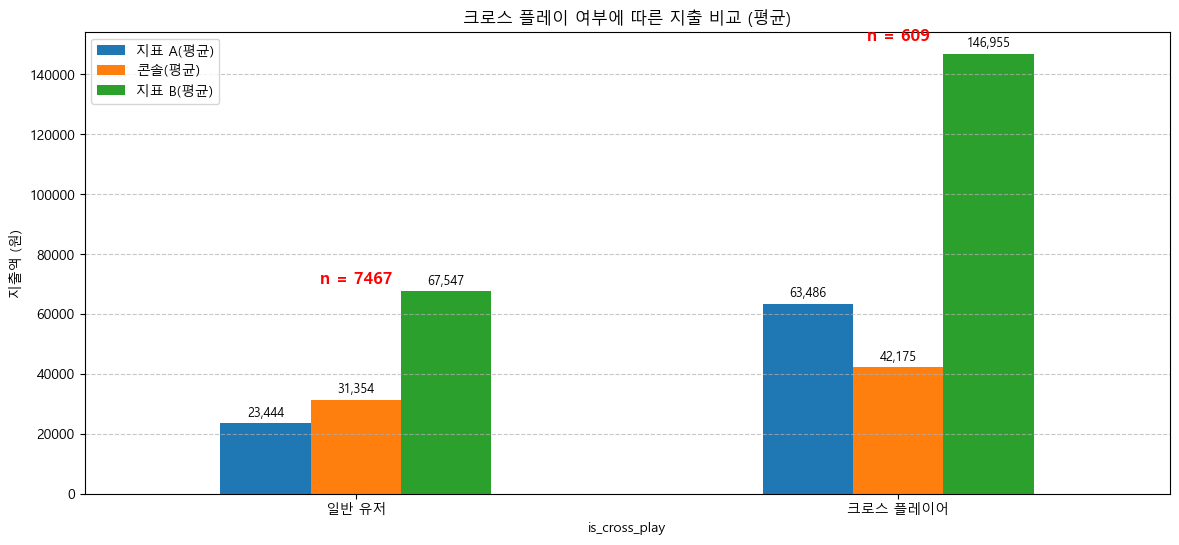

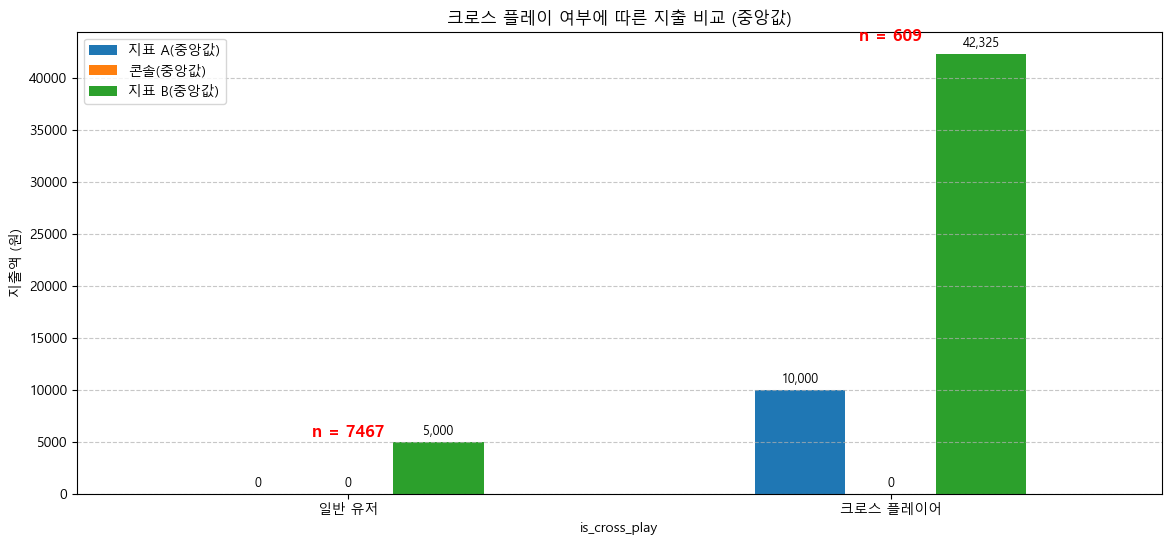

In [2]:
# ================================================== 
# 콘솔게임은 주관식 게임명 데이터가 부재하여, 타이틀 중심의 크로스 플레이 분석에서 제외했다.
# 국내 게임시장이 모바일과 PC 기반의 게임이기에, 크로스 플랫폼 간의 시너지를 분석하는 것이 실무적으로 더 유의미하다고 판단하였다.
# ================================================== 

# ================================================== 
# 각 응답자는 PC/모바일에서 즐긴 게임을 최대 3개까지 코드로 응답했다..
# 본 로직은 각 순위별 코드값을 가져와 코드북으로 게임명으로 매핑한 뒤,
# PC와 모바일 게임명 집합의 교집합이 존재하면 크로스플레이로 정의했다.
# ================================================== 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================== 
# 1. 한글 폰트 및 기본 설정
# ================================================== 
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


# ================================================== 
# 2. 데이터 불러오기
# ================================================== 
data_file = '2024_게임_이용자_실태조사_DATA_게임이름응답포함.xlsx'
codebook_file = '2024_게임_이용자_실태조사_CODEBOOK..xlsx'

df_raw = pd.read_excel(data_file, sheet_name='1. 2024 게임 이용자 실태조사_DATA_게임이름응답')
df_pc_codes = pd.read_excel(codebook_file, sheet_name='B7_2')
df_mobile_codes = pd.read_excel(codebook_file, sheet_name='C10_2')


# ================================================== 
# 3. [회계식 세부 분류] 리네이밍 딕셔너리 
# ================================================== 
rename_dict = {
    'SQ1_1': 'age_group', 'SQ3': 'gender',
    # PC (B8 계열)
    'B8_n2': 'pc_ingame_spend',    # 인게임 결제 (핵심 지표 A)
    'B8_n3': 'pc_sub_spend',       # 구독료 (Xbox Game Pass 등)
    'B8_n4': 'pc_total_spend',     # PC 총 지출
    
    # 모바일 (C12 계열)
    'C12_n2': 'mobile_ingame_spend', 
    'C12_n3': 'mobile_sub_spend',   # 구독료 (Apple Arcade 등)
    'C12_n4': 'mobile_total_spend', 
    
    # 콘솔 (D9 계열 - 콘솔은 총액 컬럼이 없어 세부 합산 필요)
    'D9_n2': 'console_physical', 'D9_n3': 'console_digital', 
    'D9_n4': 'console_ingame', 'D9_n5': 'console_sub',
    
    'B1': 'pc_freq', 'C1': 'mobile_freq',
    'B7_2': 'pc_id1', 'B7_2_n2': 'pc_id2', 'B7_2_n3': 'pc_id3',
    'C10_2': 'mobile_id1', 'C10_2_n2': 'mobile_id2', 'C10_2_n3': 'mobile_id3'
}

df_final = df_raw.rename(columns=rename_dict)[list(rename_dict.values())].copy()

# ================================================== 
# 4. 결제액 데이터 정제 (NaN -> 0)
# ================================================== 
spend_cols = [col for col in df_final.columns if 'spend' in col or 'console' in col]
df_final[spend_cols] = df_final[spend_cols].fillna(0)


# ================================================== 
# 5. [지표 계산] A: 직접 지출 vs B: 전체 지갑 vs 콘솔 독립 관리
# ================================================== 
# Indicator A: 크로스 플랫폼 직접 지출 (PC+모바일 인게임)
df_final['indicator_A_direct'] = df_final['pc_ingame_spend'] + df_final['mobile_ingame_spend']

# 콘솔 총 지출 (별도 관리 항목)
df_final['console_total_spend'] = (
    df_final['console_physical'] + df_final['console_digital'] + 
    df_final['console_ingame'] + df_final['console_sub']
)

# Indicator B: 유저 게임 결제 금액 총액 (Grand Total)
df_final['indicator_B_wallet'] = (
    df_final['pc_total_spend'] + 
    df_final['mobile_total_spend'] + 
    df_final['console_total_spend']
)


# ================================================== 
# 6. 크로스 플레이 식별 로직 (안전 버전)
# ================================================== 
def get_clean_dict(df, code_col='코드', desc_col='코드 설명'):
    d = {}
    for k, v in zip(df[code_col], df[desc_col]):
        if pd.notna(k):
            d[str(int(k))] = v
    return d

pc_dict = get_clean_dict(df_pc_codes)
mobile_dict = get_clean_dict(df_mobile_codes)

def map_game_name(val, dct):
    if pd.isna(val):
        return None
    try:
        return dct.get(str(int(val)))
    except:
        return None

def check_cross_play(row):
    pc_games = set()
    mb_games = set()

    for i in range(1, 4):
        pc_name = map_game_name(row.get(f'pc_id{i}'), pc_dict)
        mb_name = map_game_name(row.get(f'mobile_id{i}'), mobile_dict)
        if pc_name is not None:
            pc_games.add(pc_name)
        if mb_name is not None:
            mb_games.add(mb_name)

    return len(pc_games.intersection(mb_games)) > 0

df_final['is_cross_play'] = df_final.apply(check_cross_play, axis=1)


# ================================================== 
# 7. 요약 (표본수 + 평균/중앙값 + 통계 검정)
# ================================================== 
from scipy.stats import mannwhitneyu

metric_cols = ['indicator_A_direct', 'console_total_spend', 'indicator_B_wallet']

# (1) 표본수(n) + 평균(mean) + 중앙값(median)
summary = df_final.groupby('is_cross_play')[metric_cols].agg(['count', 'mean', 'median'])

# 보기 좋게 컬럼 이름 정리
summary.columns = [f"{col}_{stat}" for col, stat in summary.columns]
summary = summary.rename(index={False: '일반 유저', True: '크로스 플레이어'})

# (2) 통계 검정: Mann–Whitney U 
# 결제 금액 데이터는 일반적으로 정규분포를 따르지 않는 '롱테일(Long-tail)' 분포를 보였다. 
# 따라서 두 집단 간의 중앙값 차이를 비교하기 위해 비모수 검정 방법론인 Mann–Whitney U를 수행했다.
#     두 집단 비교: 크로스 플레이어(True) vs 일반(False)
pvals = {}
for m in metric_cols:
    a = df_final.loc[df_final['is_cross_play'] == True, m].dropna()
    b = df_final.loc[df_final['is_cross_play'] == False, m].dropna()

    # 집단 중 하나라도 데이터가 너무 적으면 검정 불가 처리
    if (len(a) < 2) or (len(b) < 2):
        pvals[m] = np.nan
        continue

    # 분포가 다르다고 가정하는 양측 검정
    _, p = mannwhitneyu(a, b, alternative='two-sided')
    pvals[m] = p

pvals_series = pd.Series(pvals, name='p_value(Mann-Whitney U)')
# summary에 p-value를 한 줄로 붙이기 위해 행으로 변환
pvals_row = pd.DataFrame([pvals_series])
pvals_row.index = ['통계검정 p-value']

# (3) 최종 보고용 테이블 만들기 (mean/median/n만 뽑아서 깔끔하게)
report = pd.DataFrame(index=summary.index)

# 표본수
report['n(표본수)'] = summary['indicator_B_wallet_count']  # 지표 중 하나 count면 동일(결측이 없다면)

# 평균/중앙값(보고서에서 보기 좋은 순서)
report['지표 A 평균'] = summary['indicator_A_direct_mean']
report['지표 A 중앙값'] = summary['indicator_A_direct_median']

report['콘솔 지출 평균'] = summary['console_total_spend_mean']
report['콘솔 지출 중앙값'] = summary['console_total_spend_median']

report['지표 B 평균'] = summary['indicator_B_wallet_mean']
report['지표 B 중앙값'] = summary['indicator_B_wallet_median']

# p-value를 따로 붙이기 (발표/보고서용)
report_with_p = pd.concat([report, pvals_row], axis=0)

print("--- [수익성 심층 분석 리포트: n + mean/median + p-value] ---")
display(report_with_p)


# ================================================== 
# 8. 시각화: 평균 vs 중앙값 비교
# ================================================== 
mean_plot = report.loc[['일반 유저', '크로스 플레이어'], ['지표 A 평균', '콘솔 지출 평균', '지표 B 평균']]
median_plot = report.loc[['일반 유저', '크로스 플레이어'], ['지표 A 중앙값', '콘솔 지출 중앙값', '지표 B 중앙값']]

mean_plot.columns = ['지표 A(평균)', '콘솔(평균)', '지표 B(평균)']
median_plot.columns = ['지표 A(중앙값)', '콘솔(중앙값)', '지표 B(중앙값)']

# (1) 평균 지출 비교 그래프
ax1 = mean_plot.plot(kind='bar', figsize=(14, 6))
for container in ax1.containers:
    ax1.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=9)

# 표본수(n) 
for i, label in enumerate(mean_plot.index):
    n_value = report.loc[label, 'n(표본수)'] # 원본 report에서 n값 가져오기
    max_y = mean_plot.loc[label].max()     # 가장 높은 막대 높이 찾기
    
    # 그래프 위에 텍스트 쓰기 (x좌표, y좌표, 내용)
    ax1.text(i, max_y + (max_y * 0.02), f'n = {int(n_value)}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')


plt.title('크로스 플레이 여부에 따른 지출 비교 (평균)')
plt.ylabel('지출액 (원)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()

# -----------------------
# (2) 중앙값 지출 비교 그래프
ax2 = median_plot.plot(kind='bar', figsize=(14, 6))
for container in ax2.containers:
    ax2.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=9)

# 표본수(n)
for i, label in enumerate(median_plot.index):
    n_value = report.loc[label, 'n(표본수)']
    max_y = median_plot.loc[label].max()
    
    ax2.text(i, max_y + (max_y * 0.02), f'n = {int(n_value)}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

plt.title('크로스 플레이 여부에 따른 지출 비교 (중앙값)')
plt.ylabel('지출액 (원)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()


,age_group_major,is_cross_play,n,mean_wallet,median_wallet,구분
0,10대,False,1135,39818.381965,3000.0,일반 유저
1,10대,True,118,73963.076271,9950.0,크로스 플레이어
2,20대,False,1591,86809.535066,21740.0,일반 유저
3,20대,True,110,177804.381818,61750.0,크로스 플레이어
4,30대,False,1572,96981.505738,15000.0,일반 유저
5,30대,True,97,244810.213402,96000.0,크로스 플레이어
6,40대,False,1477,77529.216263,3000.0,일반 유저
7,40대,True,122,167990.890164,80700.0,크로스 플레이어
8,50대 이상,False,1692,31975.796868,0.0,일반 유저
9,50대 이상,True,162,104740.061728,19620.0,크로스 플레이어


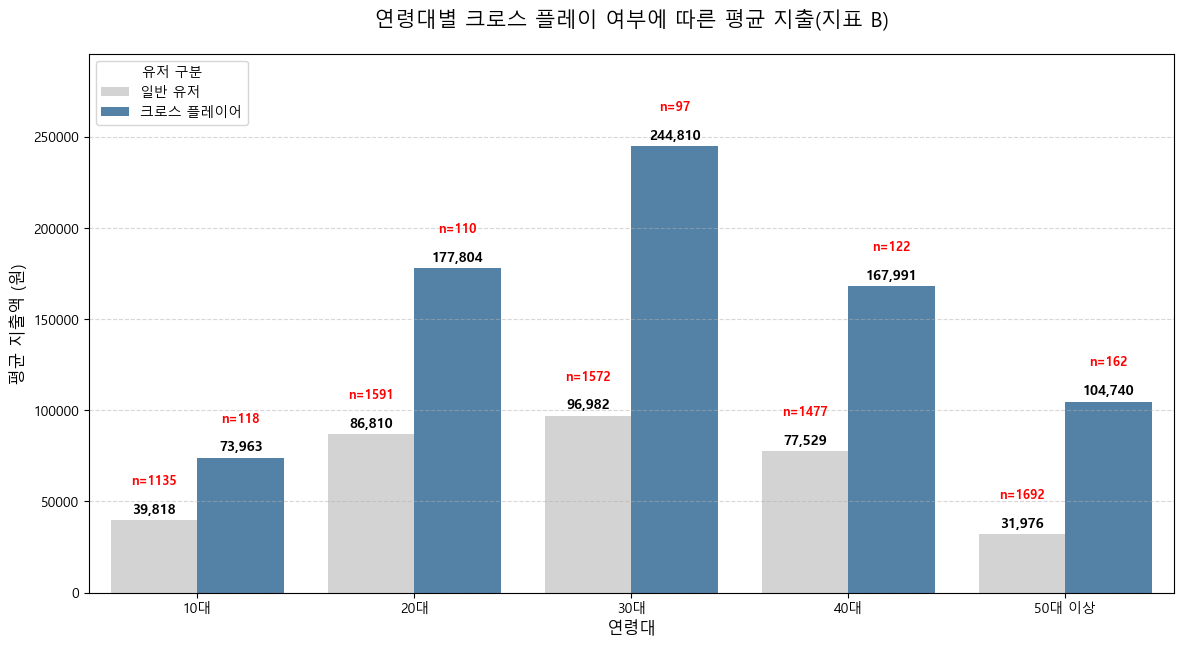

In [3]:
# ================================================== 
# 연령대별 및 크로스플레이어 지출 분석
# Q. 특정 연령대에서 크로스 플레이어의 결제 금액이 높은가?
# ================================================== 

# ================================================== 
# 1. 연령대 라벨링
# ================================================== 
def map_age_group_major(x):
    if x in [2, 3]:
        return '10대'
    elif x in [4, 5]:
        return '20대'
    elif x in [6, 7]:
        return '30대'
    elif x in [8, 9]:
        return '40대'
    elif x in [10, 11, 12, 13]:
        return '50대 이상'
    else:
        return np.nan

df_final['age_group_major'] = df_final['age_group'].apply(map_age_group_major)


# ================================================== 
# 2. 연령대 및 크로스플레이 평균 / 중앙값
# ================================================== 
age_summary = (
    df_final
    .groupby(['age_group_major', 'is_cross_play'])
    .agg(
        n=('indicator_B_wallet', 'count'),
        mean_wallet=('indicator_B_wallet', 'mean'),
        median_wallet=('indicator_B_wallet', 'median')
    )
    .reset_index()
    .sort_values(['age_group_major', 'is_cross_play'])
)

age_summary['구분'] = age_summary['is_cross_play'].map(
    {False: '일반 유저', True: '크로스 플레이어'}
)

display(age_summary)


# ================================================== 
# 3. 시각화
# ================================================== 
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=age_summary,
    x='age_group_major',
    y='mean_wallet',
    hue='구분',
    palette=['#D3D3D3', '#4682B4'] # 일반은 회색, 크로스는 푸른색으로 표시
)

# --- 1. 각 막대별 수치 표시 (검은색) ---
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10, color='black', fontweight='bold')

# --- 2. 각 막대별 표본수(n) 표시 (붉은색) ---
# hue 그룹(일반 유저, 크로스 플레이어) 순서대로 데이터를 매칭
hue_labels = ['일반 유저', '크로스 플레이어']

for i, container in enumerate(ax.containers):
    # 해당 그룹의 n값만 필터링 (데이터 정렬 순서와 막대 순서 일치 확인)
    subset = age_summary[age_summary['구분'] == hue_labels[i]]
    n_values = subset['n'].values
    
    for bar, n in zip(container, n_values):
        height = bar.get_height()
        # 수치 표시보다 조금 더 위(y축 범위의 7% 정도 위)에 n수 표시
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height + (ax.get_ylim()[1] * 0.07), 
            f'n={int(n)}',
            ha='center', va='bottom', fontsize=9, color='red', fontweight='bold'
        )

plt.title('연령대별 크로스 플레이 여부에 따른 평균 지출(지표 B)', fontsize=15, pad=20)
plt.ylabel('평균 지출액 (원)', fontsize=12)
plt.xlabel('연령대', fontsize=12)

# 텍스트가 잘리지 않도록 y축 상단 여백 확보
plt.ylim(0, ax.get_ylim()[1] * 1.15) 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='유저 구분', loc='upper left')
plt.xticks(rotation=0)
plt.show()


# ================================================== 
# 연령대별 및 크로스플레이어 지출 분석 결과
# A. 전 연령대에서 공통적으로 크로스플레이어의 지출 금액이 많았다.
# A. 특히 30대에서 일반플레이어와 크로스플레이어의 결제 금액 격차가 가장 컸다.
# ================================================== 

C:\Users\user\AppData\Local\Temp\ipykernel_26916\813727302.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['freq_group', 'is_cross_play'])


,freq_group,is_cross_play,n,mean_wallet,median_wallet
0,Low,False,3442,33804.833527,0.0
1,Low,True,51,47071.431373,0.0
2,Mid,False,2124,62184.507872,5000.0
3,Mid,True,162,76887.919753,20450.0
4,High,False,1901,134634.576454,56000.0
5,High,True,396,188482.344192,64275.0


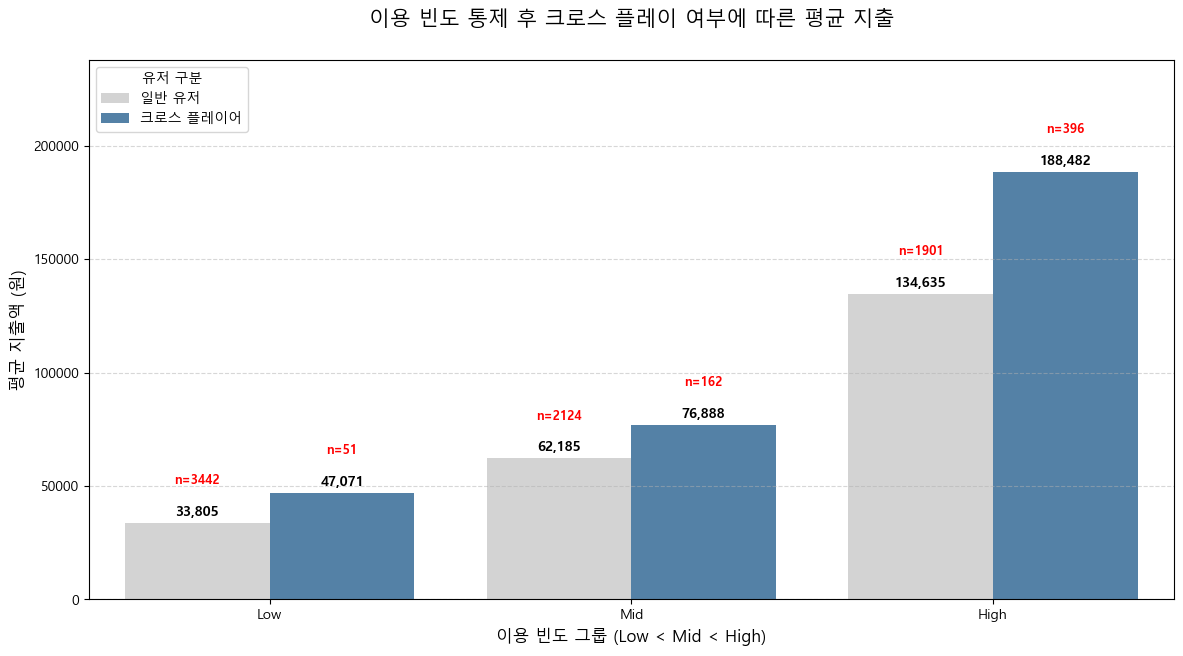

In [4]:
# ================================================== 
# PC / 모바일 이용 빈도 통제 후 비교
# "크로스 플레이어가 돈을 많이 쓰는 이유는 그냥 게임을 많이 해서 그런 건 아닐까?"
# ================================================== 


# ================================================== 
# 1. 이용 빈도 변수 준비
# ================================================== 
# pd.qcut 함수를 사용하기 위해 숫자를 거꾸로 뒤집어주기(pd.qcut은 숫자가 큰 쪽을 High로 분류하기때문)
# 원래 코드 범위: 1(자주) ~ 8(드묾)
MAX_FREQ = 8

df_final['pc_freq_adj'] = MAX_FREQ + 1 - df_final['pc_freq']
df_final['mobile_freq_adj'] = MAX_FREQ + 1 - df_final['mobile_freq']



# ================================================== 
# 2. 결측치 처리
# ================================================== 
freq_cols_adj = ['pc_freq_adj', 'mobile_freq_adj']
df_final[freq_cols_adj] = df_final[freq_cols_adj].fillna(0)

df_final['total_freq_adj'] = (
    df_final['pc_freq_adj'] + df_final['mobile_freq_adj']
)



# ================================================== 
# 3. 이용 빈도 구간화 (Low / Mid / High)
# ================================================== 
df_final['freq_group'] = pd.qcut(
    df_final['total_freq_adj'],
    q=3,
    labels=['Low', 'Mid', 'High']  # Low=저빈도, High=고빈도
)




# ================================================== 
# 4. 이용 빈도 통제 후 비교
# ================================================== 
freq_summary = (
    df_final
    .groupby(['freq_group', 'is_cross_play'])
    .agg(
        n=('indicator_B_wallet', 'count'),
        mean_wallet=('indicator_B_wallet', 'mean'),
        median_wallet=('indicator_B_wallet', 'median')
    )
    .reset_index()
)

display(freq_summary)



# ================================================== 
# 5. 시각화
# ================================================== 
 
plt.figure(figsize=(14, 7))

# 일반/크로스 구분을 위해 라벨링 변경 
freq_summary['구분'] = freq_summary['is_cross_play'].map({False: '일반 유저', True: '크로스 플레이어'})

ax = sns.barplot(
    data=freq_summary,
    x='freq_group',
    y='mean_wallet',
    hue='구분',
    palette=['#D3D3D3', '#4682B4'] # 일반-회색, 크로스-푸른색
)

# --- 1. 각 막대별 수치 표시 (검은색) ---
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10, color='black', fontweight='bold')

# --- 2. 각 막대별 표본수(n) 표시 (붉은색) ---
hue_labels = ['일반 유저', '크로스 플레이어']

for i, container in enumerate(ax.containers):
    # 해당 그룹(일반/크로스)의 n값만 필터링
    subset = freq_summary[freq_summary['구분'] == hue_labels[i]]
    n_values = subset['n'].values
    
    for bar, n in zip(container, n_values):
        height = bar.get_height()
        # 금액 표시보다 조금 더 위(y축 범위의 8% 위)에 n수 표시
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height + (ax.get_ylim()[1] * 0.08), 
            f'n={int(n)}',
            ha='center', va='bottom', fontsize=9, color='red', fontweight='bold'
        )

plt.title('이용 빈도 통제 후 크로스 플레이 여부에 따른 평균 지출', fontsize=15, pad=25)
plt.ylabel('평균 지출액 (원)', fontsize=12)
plt.xlabel('이용 빈도 그룹 (Low < Mid < High)', fontsize=12)

# 텍스트 공간 확보를 위해 y축 상단 여백 20% 추가
plt.ylim(0, ax.get_ylim()[1] * 1.2) 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='유저 구분', loc='upper left')
plt.show()


# ================================================== 
# PC / 모바일 이용 빈도 통제 후 비교 결과
# A. 게임 이용빈도가 같은 그룹 내에서도 크로스 플레이어가 게임 결제 금액이 많았다.
# ================================================== 

In [5]:
# ================================================== 
# 결제 경험 여부 분석 
# Q. "결제를 하게 만드는가?"
# ================================================== 



# ================================================== 
# 1. 결제 경험 변수 생성
# ================================================== 
df_final['has_paid'] = (df_final['indicator_B_wallet'] > 0).astype(int)



# ================================================== 
# 2. 크로스 플레이 x 결제 경험 비율
# ================================================== 
pay_rate = (
    df_final
    .groupby('is_cross_play')['has_paid']
    .agg(['mean', 'count'])
)

pay_rate['결제경험률(%)'] = pay_rate['mean'] * 100
pay_rate = pay_rate.rename(index={False: '일반 유저', True: '크로스 플레이어'})

display(pay_rate)



# ================================================== 
# 3. 결제 경험 여부 통계 검정 (카이제곱)
# ================================================== 
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_final['is_cross_play'], df_final['has_paid'])
chi2, p, _, _ = chi2_contingency(ct)

print(f"결제 경험 여부 차이 p-value (Chi-square): {p:.6f}")



# ================================================== 
# 결제 경험 여부 분석 결과
# A. 크로스 플레이 여부에 따른 결제 경험 비율 차이는 카이제곱 검정 결과 통계적으로 유의했다.
# ================================================== 




,mean,count,결제경험률(%)
is_cross_play,,,
일반 유저,0.536226,7467,53.622606
크로스 플레이어,0.725780,609,72.577997


결제 경험 여부 차이 p-value (Chi-square): 0.000000


--- [장르별 시너지 분석: PC/모바일 통합 분석 완료] ---


,indicator_A_direct_count,indicator_A_direct_mean,indicator_A_direct_median,indicator_B_wallet_count,indicator_B_wallet_mean,indicator_B_wallet_median
genre_group,,,,,,
RPG(Top3 포함),294.0,98342.583810,20000.0,294.0,219529.107619,80000.0
기타,315.0,30952.557333,0.0,315.0,79218.846540,10000.0


C:\Users\user\AppData\Local\Temp\ipykernel_26916\880439248.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


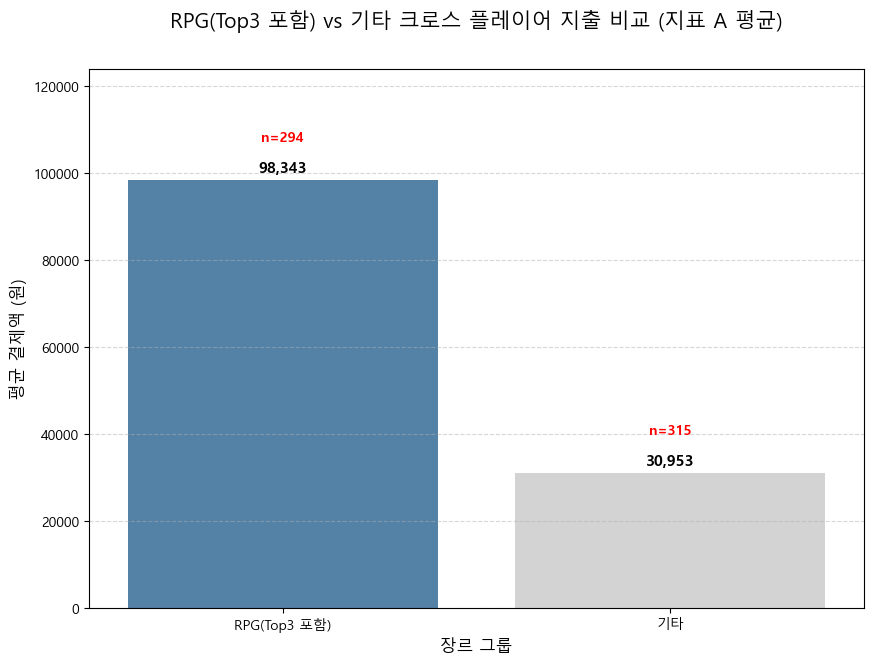

In [6]:

# ================================================== 
# RPG 크로스 플레이어 vs 기타 장르 크로스 플레이어의 지출 비교
#   - 장르 Top3 컬럼(df_raw) -> df_final에 join
#   - 모바일 대표 장르(Top1 -> Top2 -> Top3) 기반으로 RPG/기타 분류
#   - 크로스 플레이어만 대상으로 지출 비교 + 통계검정 + 시각화
#   ※ 콘솔 장르 제외 (PC·모바일 기준 분석)
# ==================================================


# ==================================================
# 1. rename_dict 업데이트
# ==================================================
rename_dict.update({
    'B4_1': 'pc_genre1', 'B4_1_m2': 'pc_genre2', 'B4_1_m3': 'pc_genre3',
    'C5_1': 'mobile_genre1', 'C5_1_m2': 'mobile_genre2', 'C5_1_m3': 'mobile_genre3'
})


# ==================================================
# 2. df_final에 장르 컬럼 추가
# ==================================================
genre_cols_raw = ['B4_1', 'B4_1_m2', 'B4_1_m3', 'C5_1', 'C5_1_m2', 'C5_1_m3']
for col in genre_cols_raw:
    if col in df_raw.columns:
        df_final[rename_dict[col]] = df_raw[col]


# ==================================================
# 3. PC + 모바일 통합 RPG 그룹화 (Top3 내 포함 기준)
# ==================================================
RPG_CODE = 1
target_genre_cols = [rename_dict[c] for c in genre_cols_raw if c in df_raw.columns]

# 만약 target_genre_cols가 비면(컬럼명을 잘못 넣었거나) 바로 알려주기
if len(target_genre_cols) == 0:
    raise KeyError("PC/모바일 장르 컬럼을 df_raw에서 찾지 못했습니다. 컬럼명(B4_1/C5_1...) 확인 필요")

df_final['is_rpg_any_top3'] = (df_final[target_genre_cols] == RPG_CODE).any(axis=1)

# 장르 무응답(6개 전부 NaN) 따로 빼기:
all_missing = df_final[target_genre_cols].isna().all(axis=1)
df_final['genre_group'] = np.select(
    [all_missing, df_final['is_rpg_any_top3']],
    ['미상', 'RPG(Top3 포함)'],
    default='기타'
)


# ==================================================
# 4. is_cross_play가 없으면 기존 안전함수로 생성 (변수명 통일)
# ==================================================
if 'is_cross_play' not in df_final.columns:
    print("is_cross_play가 없어서 다시 생성합니다.")

    def map_game_name_safe(val, dct):
        if pd.isna(val):
            return None
        try:
            return dct.get(str(int(float(val))))
        except:
            return None

    def check_cp(row):
        pc = set()
        mb = set()
        for i in range(1, 4):
            pc_name = map_game_name_safe(row.get(f'pc_id{i}'), pc_dict)
            mb_name = map_game_name_safe(row.get(f'mobile_id{i}'), mobile_dict)
            if pc_name:
                pc.add(pc_name)
            if mb_name:
                mb.add(mb_name)
        return len(pc.intersection(mb)) > 0

    df_final['is_cross_play'] = df_final.apply(check_cp, axis=1)


# ==================================================
# 5. 분석 대상: 크로스 플레이어만
# ==================================================
cross_df = df_final[df_final['is_cross_play'] == True].copy()


# ==================================================
# 6. 요약
# ==================================================
METRICS = ['indicator_A_direct', 'indicator_B_wallet']
missing_metrics = [m for m in METRICS if m not in cross_df.columns]
if missing_metrics:
    raise KeyError(f"지표 컬럼이 없습니다: {missing_metrics}. indicator 계산 파트 실행 필요")

rpg_analysis = cross_df.groupby('genre_group')[METRICS].agg(['count', 'mean', 'median'])
rpg_analysis.columns = [f"{col}_{stat}" for col, stat in rpg_analysis.columns]

print("--- [장르별 시너지 분석: PC/모바일 통합 분석 완료] ---")
display(rpg_analysis.reindex(['RPG(Top3 포함)', '기타', '미상']).dropna(how='all'))
    


# ==================================================
# 7. 시각화 (지표 A 평균)
# ==================================================

plt.figure(figsize=(10, 7))

# RPG 그룹만 강조하기 위한 색상 설정
# 인덱스 순서에 맞춰 'RPG(Top3 포함)'는 푸른색, 나머지는 회색
colors = ['#4682B4' if 'RPG' in x else '#D3D3D3' for x in rpg_analysis.index]

ax = sns.barplot(
    x=rpg_analysis.index, 
    y=rpg_analysis['indicator_A_direct_mean'],
    palette=colors
)

# --- 1. 각 막대별 수치 표시 (검은색) ---
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=11, color='black', fontweight='bold')

# --- 2. 각 막대별 표본수(n) 표시 (붉은색) ---
for i, label in enumerate(rpg_analysis.index):
    # n값 가져오기 (지표 A의 count 사용)
    n_value = rpg_analysis.loc[label, 'indicator_A_direct_count']
    height = rpg_analysis.loc[label, 'indicator_A_direct_mean']
    
    # 금액 수치보다 조금 더 위(전체 높이의 약 8% 위)에 n수 표시
    ax.text(
        i, 
        height + (ax.get_ylim()[1] * 0.08), 
        f'n={int(n_value)}',
        ha='center', va='bottom', fontsize=10, color='red', fontweight='bold'
    )

plt.title('RPG(Top3 포함) vs 기타 크로스 플레이어 지출 비교 (지표 A 평균)', fontsize=15, pad=30)
plt.ylabel('평균 결제액 (원)', fontsize=12)
plt.xlabel('장르 그룹', fontsize=12)

# 텍스트가 잘리지 않도록 y축 상단 여백 확보
plt.ylim(0, ax.get_ylim()[1] * 1.2) 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## 🏁 최종 결론 및 비즈니스 제언
1. **크로스 플레이어는 고가치 유저:** 모든 지표에서 일반 유저 대비 통계적으로 유의미하게 높은 지출을 보임.
2. **RPG 장르의 시너지:** 특히 RPG 유저에서 수익성 증대 효과가 가장 크므로, 신작 출시 시 멀티플랫폼 환경 구축이 필수적임.
3. **타겟 마케팅 제안:** 결제 경험률이 높은 크로스 플레이어들을 대상으로 한 전용 프로모션을 통해 충성도를 더욱 강화할 필요가 있음.